In [1]:
import numpy as np
import pandas as pd

In [2]:
fold0 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold0_all_data.tsv", sep="\t")

In [3]:
fold0["fold"] = [0 for i in range(len(fold0))]

In [4]:
fold1 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold1_all_data.tsv", sep="\t")

In [5]:
fold1["fold"] = [1 for i in range(len(fold1))]

In [6]:
fold2 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold2_all_data.tsv", sep="\t")

In [7]:
fold2["fold"] = [2 for i in range(len(fold2))]

In [8]:
df = pd.concat([fold0, fold1, fold2], ignore_index=True)

In [9]:
len(df)

164

In [10]:
df['optimization_successful'] = df['SCD'] > 50

In [12]:
df[df["SCD"] < 50]

,chrom,start_query,end_query,centered_start,centered_end,last_accepted_step_query,active_count,neutral_count,repressive_count,total,...,num_edits,GC_seq,GC_slice,GC_slice_edited,init_CTCFs_num,CTCFs_num,FIMO_sum,FIMO_max,fold,optimization_successful
18,chr4,95569920,95807488,95033344,96344064,757,3.0,5.0,1.0,9.0,...,580.0,0.411942,0.364746,0.365723,0,0,0.0,0.0,0,False
73,chr1,185933824,186204160,185413632,186724352,460,10.0,13.0,2.0,25.0,...,501.0,0.428371,0.377930,0.411621,0,0,0.0,0.0,1,False
106,chr11,40241152,40503296,39716864,41027584,387,4.0,5.0,0.0,9.0,...,466.0,0.389825,0.356934,0.349609,0,0,0.0,0.0,2,False
129,chr16,83890176,84422656,83501056,84811776,589,8.0,10.0,1.0,19.0,...,562.0,0.380978,0.393066,0.411621,0,0,0.0,0.0,2,False


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df_melted = df.melt(value_vars=['URQ_result', 'URQ_target'], var_name='Type', value_name='URQ mean')

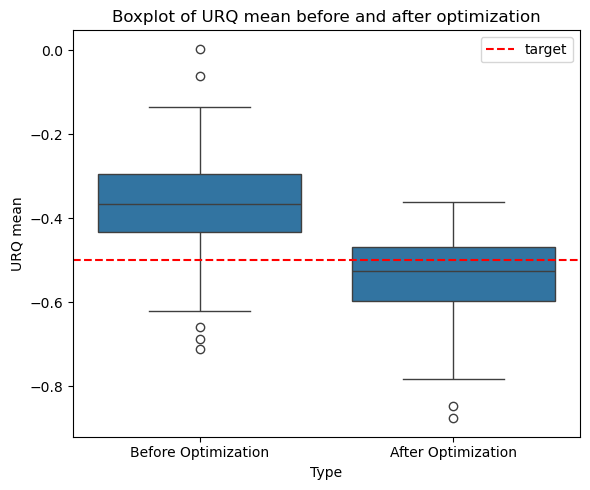

In [15]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='Type', y='URQ mean', data=df_melted)
plt.axhline(y=-0.5, color='red', linestyle='--', linewidth=1.5, label='target')
plt.xticks([0, 1], ['Before Optimization', 'After Optimization'])
plt.title('Boxplot of URQ mean before and after optimization')
plt.legend()
plt.tight_layout()
plt.show()

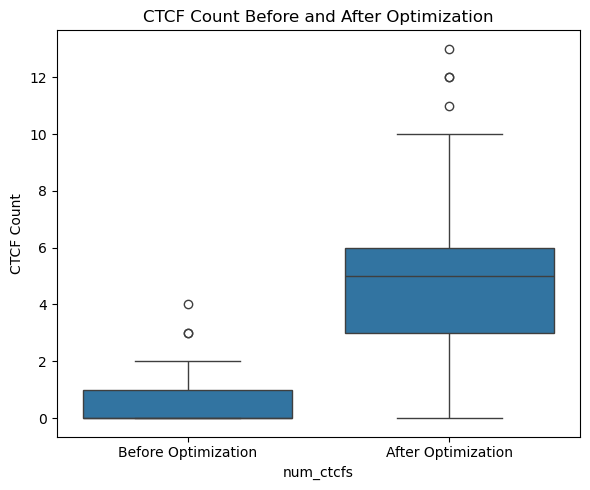

In [27]:
df_box_melted = df.melt(value_vars=['init_CTCFs_num', 'CTCFs_num'],
                            var_name='num_ctcfs', value_name='CTCF Count')

# Rename the categories for clarity
label_map = {
    'init_CTCFs_num': 'Before Optimization',
    'CTCFs_num': 'After Optimization'
}
df_box_melted['num_ctcfs'] = df_box_melted['num_ctcfs'].map(label_map)

# Plotting
plt.figure(figsize=(6, 5))
sns.boxplot(x='num_ctcfs', y='CTCF Count', data=df_box_melted)
plt.title('CTCF Count Before and After Optimization')
plt.tight_layout()
plt.show()

In [16]:
from scipy.stats import pearsonr

In [17]:

# Calculate Pearson correlation coefficient
r_value, p_value = pearsonr(df['URQ_target'], df['URQ_result'])

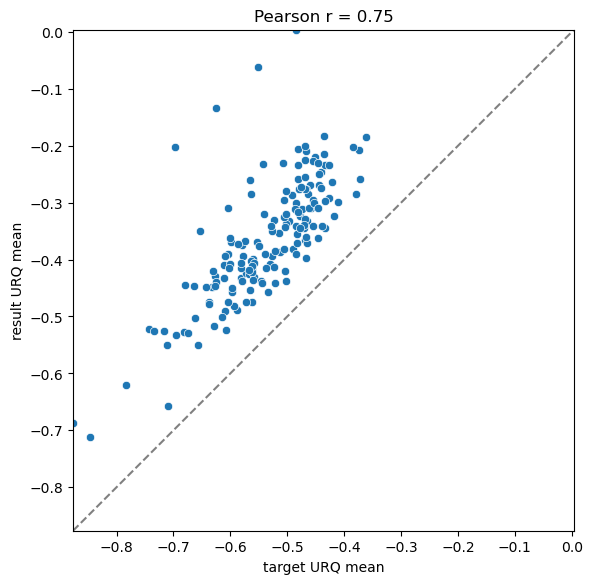

In [18]:
# Determine shared range for both axes
min_val = min(df['URQ_target'].min(), df['URQ_result'].min())
max_val = max(df['URQ_target'].max(), df['URQ_result'].max())

# Plotting the scatterplot with equal axis limits and square aspect ratio
plt.figure(figsize=(6, 6))
sns.scatterplot(x='URQ_target', y='URQ_result', data=df)
plt.plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--')  # reference diagonal
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.gca().set_aspect('equal', adjustable='box')
plt.title(f'Pearson r = {r_value:.2f}')
plt.xlabel('target URQ mean')
plt.ylabel('result URQ mean')
plt.tight_layout()
plt.show()


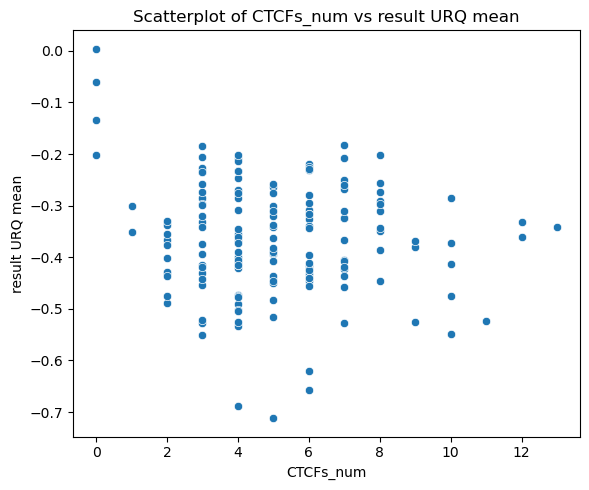

In [19]:
plt.figure(figsize=(6, 5))
sns.scatterplot(x='CTCFs_num', y='URQ_result', data=df)
plt.xlabel('CTCFs_num')
plt.ylabel('result URQ mean')
plt.title('Scatterplot of CTCFs_num vs result URQ mean')
plt.tight_layout()
plt.show()

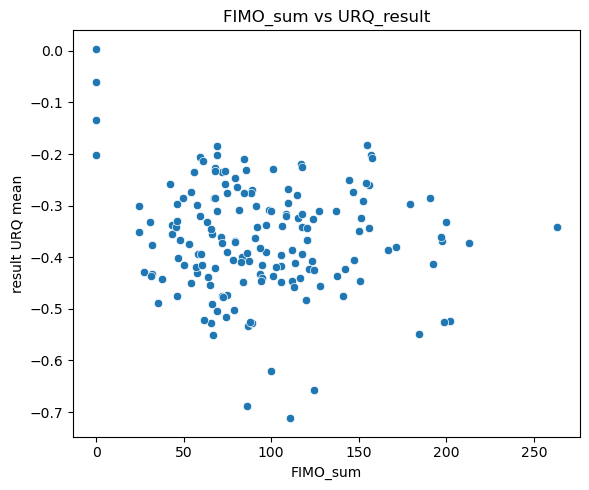

In [20]:
# Plotting the scatterplot
plt.figure(figsize=(6, 5))
sns.scatterplot(x='FIMO_sum', y='URQ_result', data=df)
plt.xlabel('FIMO_sum')
plt.ylabel('result URQ mean')
plt.title(f'FIMO_sum vs URQ_result')
plt.tight_layout()
plt.show()

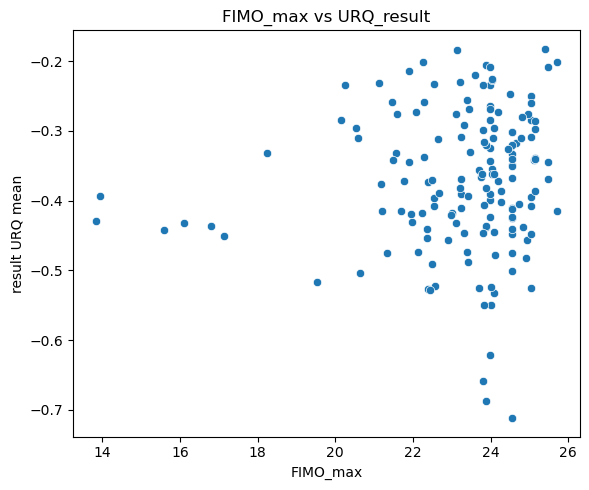

In [21]:
# Plotting the scatterplot
plt.figure(figsize=(6, 5))
sns.scatterplot(x='FIMO_max', y='URQ_result', data=df[df["SCD"] > 50])
plt.xlabel('FIMO_max')
plt.ylabel('result URQ mean')
plt.title(f'FIMO_max vs URQ_result')
plt.tight_layout()
plt.show()

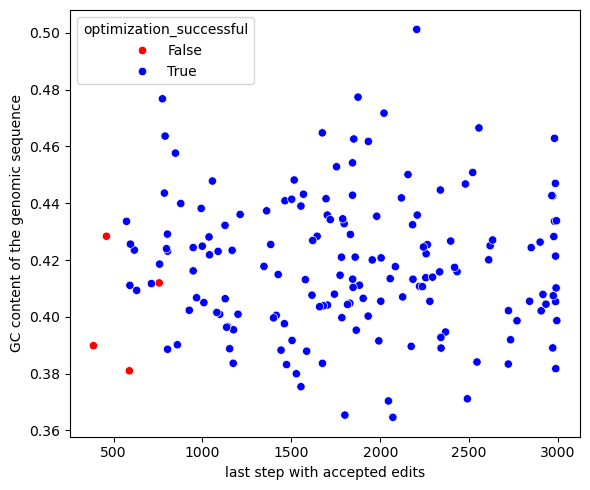

In [23]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='last_accepted_step_query',
    y='GC_seq',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('last step with accepted edits')
plt.ylabel('GC content of the genomic sequence')
plt.tight_layout()
plt.show()

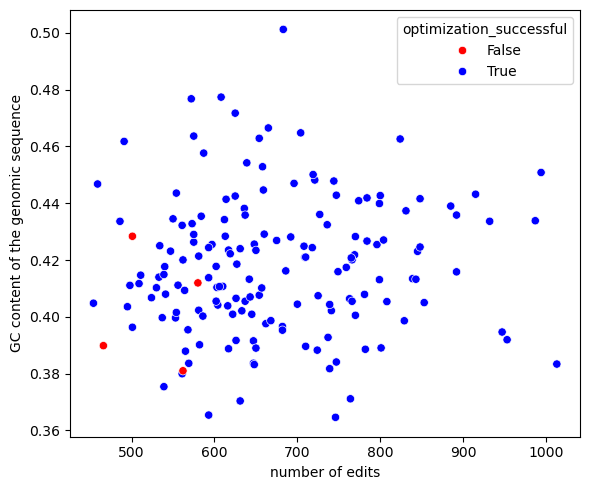

In [24]:
plt.figure(figsize=(6, 5))

sns.scatterplot(
    x='num_edits',
    y='GC_seq',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)

plt.xlabel('number of edits')
plt.ylabel('GC content of the genomic sequence')
plt.tight_layout()
plt.show()

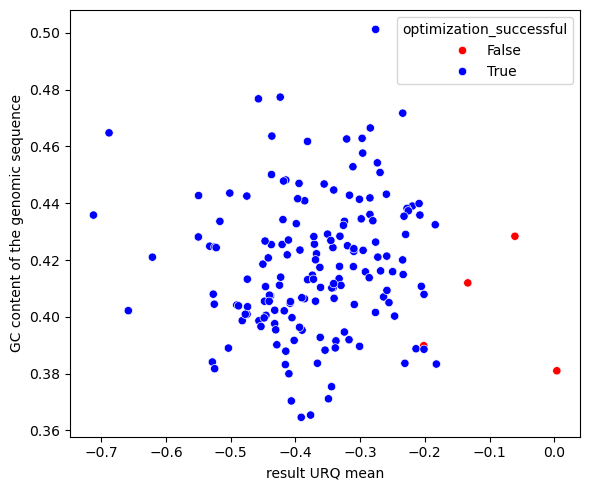

In [25]:
plt.figure(figsize=(6, 5))

sns.scatterplot(
    x='URQ_result',
    y='GC_seq',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)

plt.xlabel('result URQ mean')
plt.ylabel('GC content of the genomic sequence')
plt.tight_layout()
plt.show()

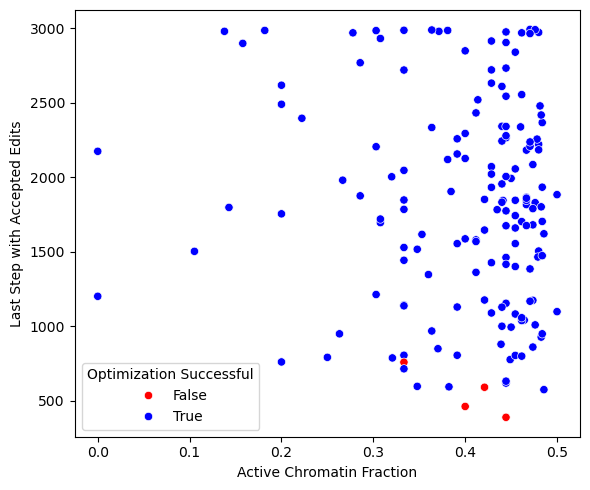

In [28]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='active_fraction',
    y='last_accepted_step_query',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Active Chromatin Fraction')
plt.ylabel('Last Step with Accepted Edits')
plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()


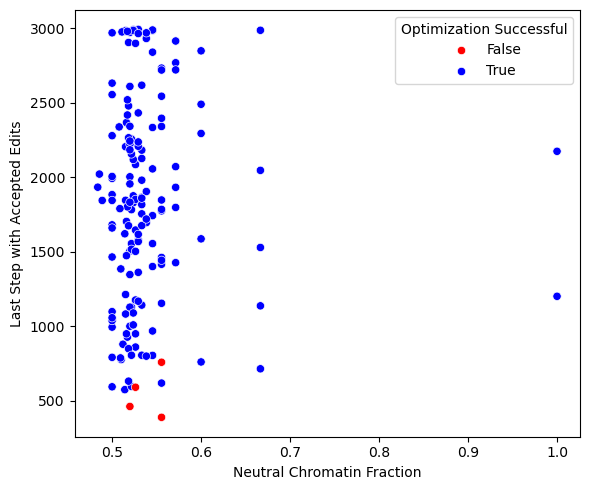

In [29]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='neutral_fraction',
    y='last_accepted_step_query',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Neutral Chromatin Fraction')
plt.ylabel('Last Step with Accepted Edits')
plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

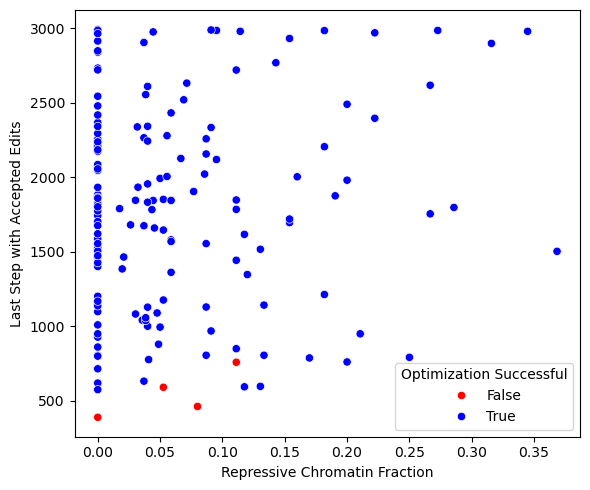

In [30]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='repressive_fraction',
    y='last_accepted_step_query',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Repressive Chromatin Fraction')
plt.ylabel('Last Step with Accepted Edits')
plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

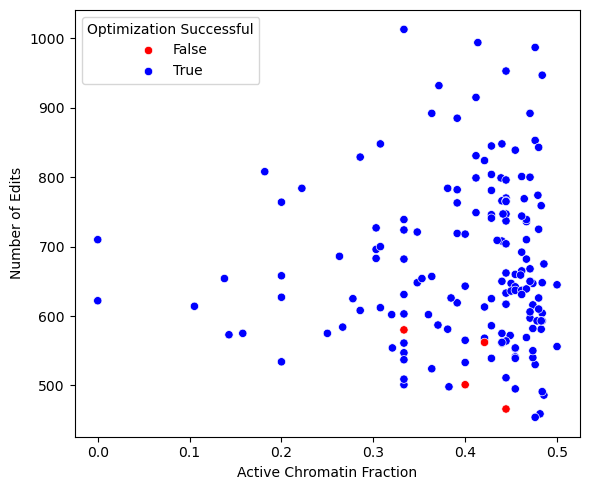

In [31]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='active_fraction',
    y='num_edits',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Active Chromatin Fraction')
plt.ylabel('Number of Edits')
plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

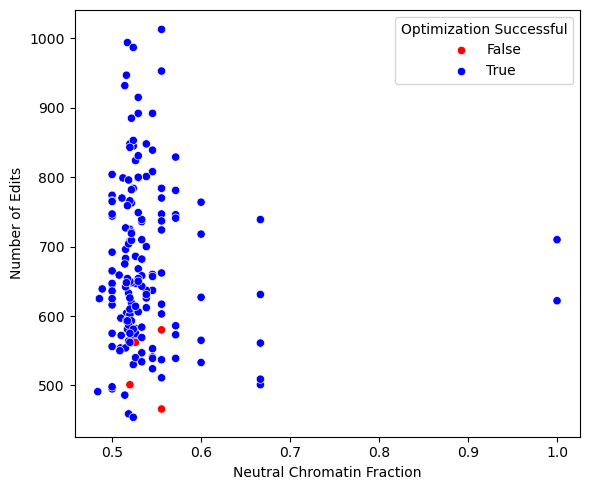

In [33]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='neutral_fraction',
    y='num_edits',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Neutral Chromatin Fraction')
plt.ylabel('Number of Edits')
plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

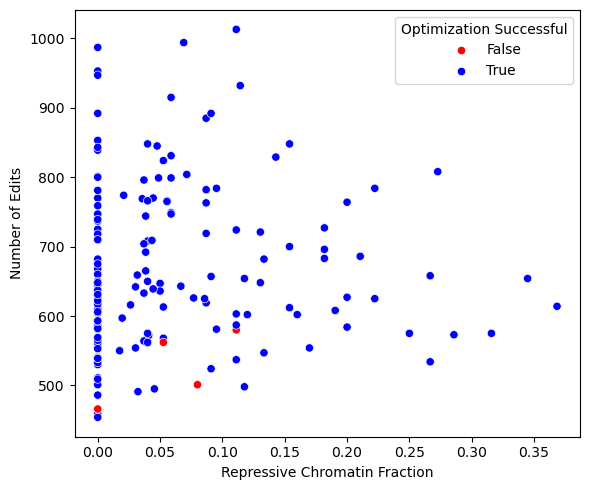

In [34]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='repressive_fraction',
    y='num_edits',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Repressive Chromatin Fraction')
plt.ylabel('Number of Edits')
plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

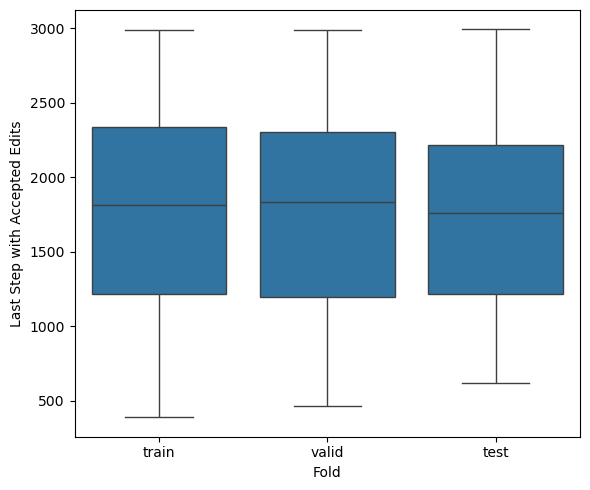

In [35]:
fold_map = {0: 'test', 1: 'valid', 2: 'train'}
df['set'] = df['fold'].map(fold_map)

# Plotting the boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(x='set', y='last_accepted_step_query', data=df, order=['train', 'valid', 'test'])
plt.xlabel('Fold')
plt.ylabel('Last Step with Accepted Edits')
plt.tight_layout()
plt.show()

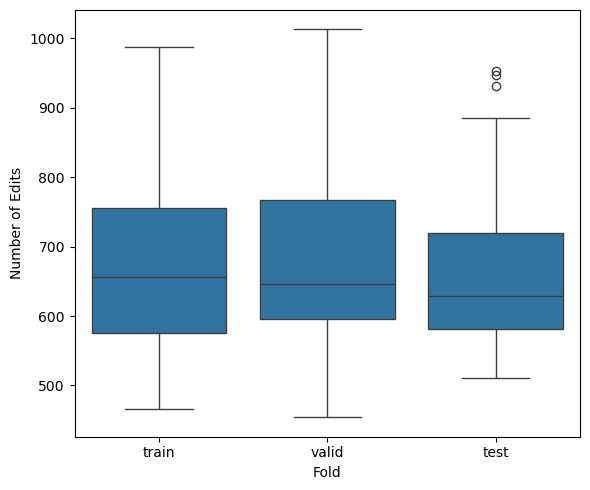

In [36]:
# Plotting the boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(x='set', y='num_edits', data=df, order=['train', 'valid', 'test'])
plt.xlabel('Fold')
plt.ylabel('Number of Edits')
plt.tight_layout()
plt.show()

In [39]:
from scipy.stats import ttest_rel

In [40]:
t_stat, p_val = ttest_rel(df['GC_slice'], df['GC_slice_edited'])

In [41]:
t_stat, p_val

(-10.628345779363114, 2.2362829611236995e-20)

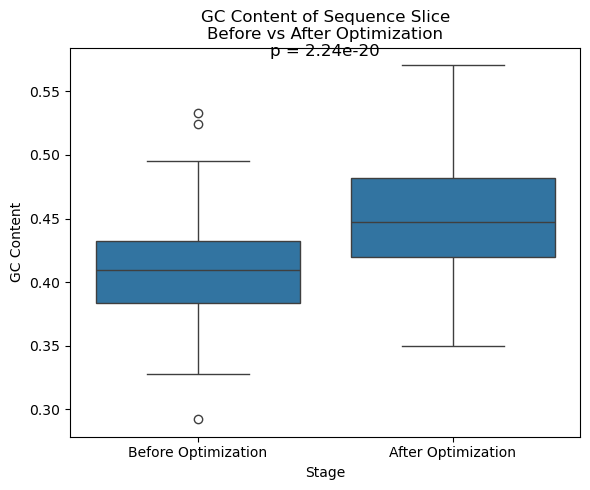

In [42]:
# Melt the DataFrame for plotting
df_gc_melted = df.melt(value_vars=['GC_slice', 'GC_slice_edited'],
                          var_name='Stage', value_name='GC Content')

# Rename the stages for clarity
stage_map = {
    'GC_slice': 'Before Optimization',
    'GC_slice_edited': 'After Optimization'
}
df_gc_melted['Stage'] = df_gc_melted['Stage'].map(stage_map)

# Plotting the boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(x='Stage', y='GC Content', data=df_gc_melted)
plt.title('GC Content of Sequence Slice\nBefore vs After Optimization')
plt.text(0.5, max(df_gc_melted['GC Content']) + 0.005,
         f'p = {p_val:.3g}', ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

In [26]:
df.columns

Index(['chrom', 'start_query', 'end_query', 'centered_start', 'centered_end',
       'last_accepted_step_query', 'active_count', 'neutral_count',
       'repressive_count', 'total', 'active_fraction', 'neutral_fraction',
       'repressive_fraction', 'SCD', 'URQ_result', 'URQ_target', 'num_edits',
       'GC_seq', 'GC_slice', 'GC_slice_edited', 'init_CTCFs_num', 'CTCFs_num',
       'FIMO_sum', 'FIMO_max', 'fold', 'optimization_successful'],
      dtype='object')